# MCR Hyperspectral Unmixing

This notebook demonstrates **Multivariate Curve Resolution (MCR)** applied to a synthetic hyperspectral imaging (HSI) dataset. MCR decomposes a mixed-signal data matrix into pure spectral components and their spatial concentration maps.

## Problem

A hyperspectral image follows the **bilinear mixing model**:

$$\mathbf{D} = \mathbf{C}\,\mathbf{S}^T + \mathbf{E}$$

where:
- $\mathbf{D} \in \mathbb{R}^{n_\text{pixels} \times n_\text{freq}}$ is the observed (noisy) data
- $\mathbf{C} \in \mathbb{R}^{n_\text{pixels} \times k}$ is the concentration matrix ($k$ components)
- $\mathbf{S}^T \in \mathbb{R}^{k \times n_\text{freq}}$ is the spectral matrix (pure spectra as rows)
- $\mathbf{E}$ is additive Gaussian noise ($\sigma = 250$)

The inverse problem — recovering $\mathbf{C}$ and $\mathbf{S}^T$ from noisy $\mathbf{D}$ — is ill-posed due to **rotational ambiguity**: any invertible $\mathbf{T}$ gives $\mathbf{D} = (\mathbf{C}\mathbf{T})(\mathbf{T}^{-1}\mathbf{S}^T)$. Physical constraints (non-negativity, normalisation, shape priors) resolve this.

We compare **5 MCR-AR variants** from the pyMCR paper (Camp 2019, J. Res. NIST):

| Method | C Regressor | S^T Regressor | Key Constraint |
|--------|------------|---------------|----------------|
| MCR-ALS | OLS | OLS | Non-neg + Norm |
| MCR-NNLS | NNLS | NNLS | Norm only on C |
| MCR-AR Gauss | NNLS | NNLS | Gaussian shape on S^T |
| MCR-AR Ridge | OLS | Ridge($\alpha$=10) | L2 penalty on S^T |
| MCR-AR Lasso | Lasso($\alpha$=1) | OLS | L1 sparsity on C |

In [1]:
import sys
import pathlib
import json

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['legend.fontsize'] = 8

TASK_DIR = pathlib.Path().resolve().parent
sys.path.insert(0, str(TASK_DIR))

from src.preprocessing import load_observation, load_ground_truth, load_metadata, estimate_initial_spectra
from src.physics_model import forward, mse
from src.visualization import (
    compute_metrics, compute_method_metrics,
    plot_spectral_components, plot_concentration_maps,
    plot_comparison_boxplots, plot_method_result,
)

DATA_DIR = TASK_DIR / "data"
OUTPUT_DIR = TASK_DIR / "output"
REF_DIR = TASK_DIR / "evaluation" / "reference_outputs"

## 1. Load Data and Ground Truth

The synthetic dataset consists of:
- **3 Gaussian spectral components** (centres at 1200, 1600, 2000 au; widths 300, 500, 300)
- **2D Gaussian concentration maps** (50 x 100 pixels) with random mixed-composition patches
- **Noisy HSI**: $\mathbf{D} = \mathbf{C}\mathbf{S}^T + \mathcal{N}(0, 250^2)$

In [2]:
obs = load_observation(DATA_DIR)
gt = load_ground_truth(DATA_DIR)
meta = load_metadata(DATA_DIR)

hsi_noisy = obs["hsi_noisy"]
wn = obs["wn"]
conc = gt["concentrations"]
conc_ravel = gt["concentrations_ravel"]
spectra = gt["spectra"]
hsi_clean = gt["hsi_clean"]

M, N, n_components = meta["M"], meta["N"], meta["n_components"]
print(f"HSI shape: {hsi_noisy.shape}  (M={M}, N={N}, n_freq={wn.size})")
print(f"Components: {n_components}")
print(f"Noise std: {meta['noise_std']}")
print(f"Wavenumber range: {wn[0]:.0f} - {wn[-1]:.0f}")

HSI shape: (5000, 200)  (M=50, N=100, n_freq=200)
Components: 3
Noise std: 250.0
Wavenumber range: 400 - 2800


### True Spectral Components

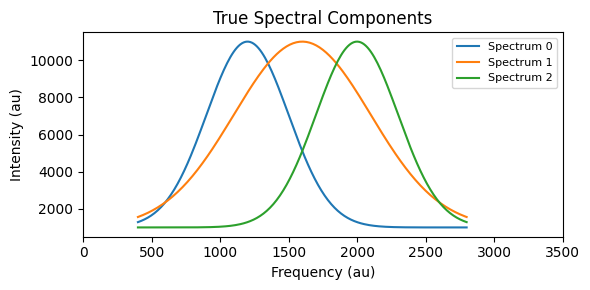

In [3]:
fig, ax = plt.subplots(figsize=(6, 3))
plot_spectral_components(ax, wn, spectra, title="True Spectral Components")
ax.set_xlim(0, 3500)
fig.tight_layout()
plt.show()

### True Concentration Maps

Each pixel sums to 1 across components. The maps are 2D Gaussians with small patches of random mixed composition.

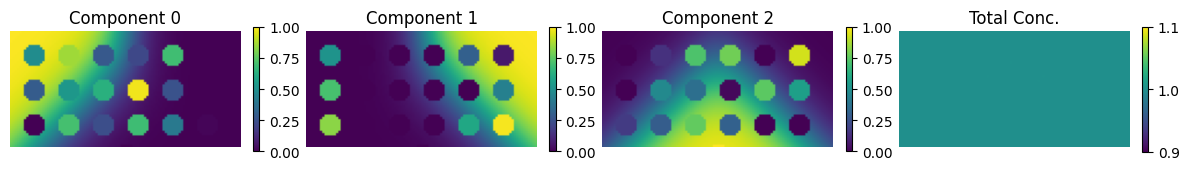

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(12, 2.5))
for k in range(n_components):
    im = axes[k].imshow(conc[..., k], vmin=0, vmax=1)
    fig.colorbar(im, ax=axes[k], fraction=0.025)
    axes[k].axis("off")
    axes[k].set_title(f"Component {k}")

im = axes[3].imshow(conc.sum(axis=-1), vmin=0.9, vmax=1.1)
fig.colorbar(im, ax=axes[3], fraction=0.025)
axes[3].axis("off")
axes[3].set_title("Total Conc.")
fig.tight_layout()
plt.show()

## 2. Initial Spectral Guess (SVD)

The initial guess for MCR is obtained from the top singular vectors of the noisy data matrix. We take $k+1 = 4$ components from truncated SVD, drop the smallest, and scale the absolute values.

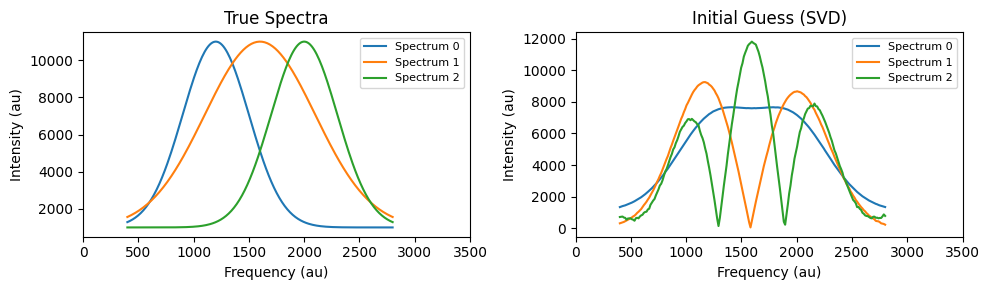

In [5]:
initial_spectra = estimate_initial_spectra(hsi_noisy, n_components)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
plot_spectral_components(axes[0], wn, spectra, title="True Spectra")
plot_spectral_components(axes[1], wn, initial_spectra, title="Initial Guess (SVD)")
axes[0].set_xlim(0, 3500)
axes[1].set_xlim(0, 3500)
fig.tight_layout()
plt.show()

## 3. MCR Reconstruction Results

We load precomputed results from `output/` (generated by `python main.py`). Each method's output includes the optimised concentration matrix $\mathbf{C}$, spectral matrix $\mathbf{S}^T$, and the reconstructed data $\mathbf{D}_\text{opt}$.

To **rerun from scratch** (takes ~6 minutes), uncomment the cell below.

In [6]:
# ---- Uncomment to rerun MCR from scratch ----
# from src.solvers import run_all_methods
# results = run_all_methods(hsi_noisy, initial_spectra, conc_ravel, spectra)

In [7]:
# Load precomputed results
method_names = ["MCR-ALS", "MCR-NNLS", "MCR-AR Gauss", "MCR-AR Ridge", "MCR-AR Lasso"]
precomputed = {}
for name in method_names:
    fname = name.replace(" ", "_") + ".npz"
    data = np.load(OUTPUT_DIR / fname)
    precomputed[name] = {
        "C_opt": data["C_opt"],
        "ST_opt": data["ST_opt"],
        "D_opt": data["D_opt"],
        "err": data["err"],
        "select": data["select"].tolist(),
    }

# Load metrics summary
with open(OUTPUT_DIR / "metrics_summary.json") as f:
    all_metrics = json.load(f)

print("Loaded precomputed results for:", list(precomputed.keys()))

Loaded precomputed results for: ['MCR-ALS', 'MCR-NNLS', 'MCR-AR Gauss', 'MCR-AR Ridge', 'MCR-AR Lasso']


### Metrics Summary

| Metric | Description |
|--------|-------------|
| **Conc NCC** | Normalised cross-correlation between true and retrieved concentrations (higher = better, max 1) |
| **Conc NRMSE** | NRMSE of concentrations (lower = better) |
| **Spec NCC** | NCC of retrieved spectra vs true spectra |
| **MSE** | Mean squared error of the data reconstruction $\|\mathbf{D} - \mathbf{C}\mathbf{S}^T\|^2 / N$ |

In [8]:
print(f"{'Method':<16} {'Conc NCC':>10} {'Conc NRMSE':>12} {'Spec NCC':>10} {'MSE':>12}")
print("-" * 64)
for name in method_names:
    m = all_metrics[name]
    print(f"{name:<16} {m['conc_ncc']:>10.4f} {m['conc_nrmse']:>12.4f} {m['spec_ncc']:>10.4f} {m['mse']:>12.2e}")

Method             Conc NCC   Conc NRMSE   Spec NCC          MSE
----------------------------------------------------------------
MCR-ALS              0.9004       0.2097     0.9795     1.83e+05
MCR-NNLS             0.9773       0.1141     0.9880     6.32e+04
MCR-AR Gauss         0.9997       0.0115     1.0000     6.30e+04
MCR-AR Ridge         0.9024       0.2078     0.9814     1.68e+05
MCR-AR Lasso         0.9817       0.0969     0.9942     6.36e+04


### MSE Convergence

All methods start from the same SVD-based initial guess. The dashed line shows the ideal MSE (noise floor).

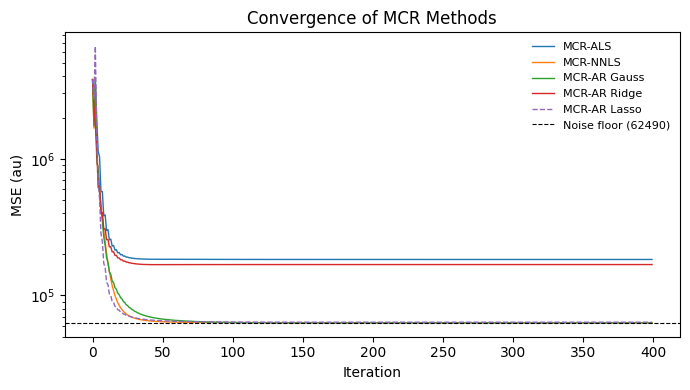

In [9]:
ideal_mse = np.mean((hsi_clean - hsi_noisy) ** 2)

fig, ax = plt.subplots(figsize=(7, 4))
for i, name in enumerate(method_names):
    ls = "--" if i == 4 else "-"
    ax.semilogy(precomputed[name]["err"], label=name, ls=ls, lw=1)
ax.axhline(ideal_mse, color="k", lw=0.8, ls="--", label=f"Noise floor ({ideal_mse:.0f})")
ax.set_xlabel("Iteration")
ax.set_ylabel("MSE (au)")
ax.set_title("Convergence of MCR Methods")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 4. Retrieved Spectra Comparison

For each method, we compare the retrieved spectral components (solid) against the true spectra (dashed).

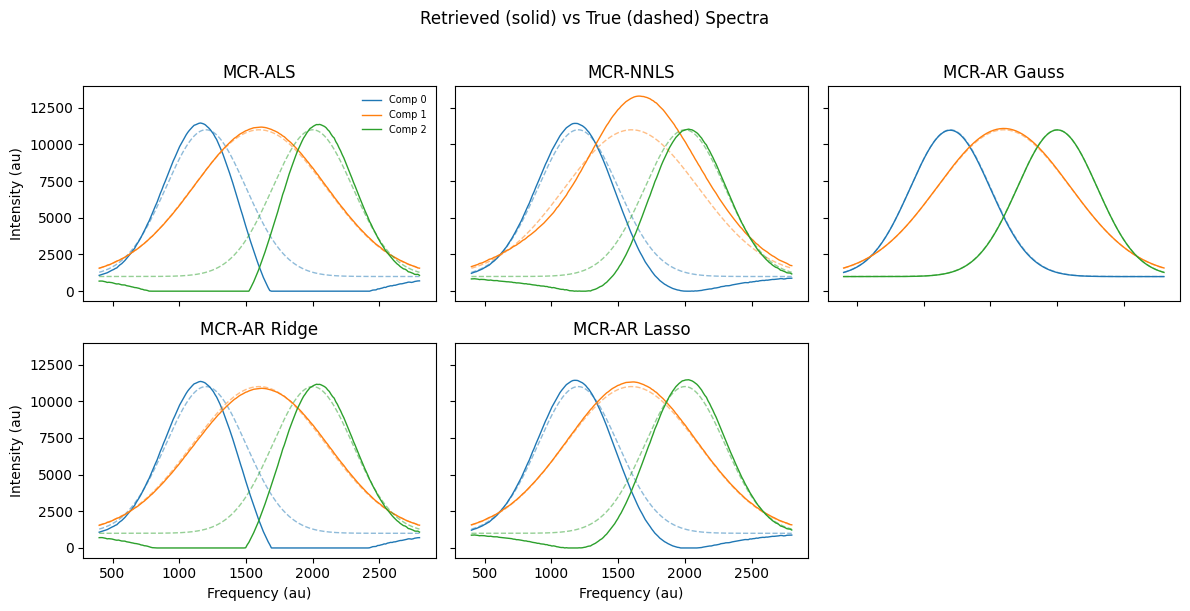

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
axes = axes.ravel()

for idx, name in enumerate(method_names):
    ax = axes[idx]
    ST_opt = precomputed[name]["ST_opt"]
    for k in range(n_components):
        ax.plot(wn, spectra[k], ls="--", color=f"C{k}", alpha=0.5, lw=1)
        ax.plot(wn, ST_opt[k], color=f"C{k}", lw=1, label=f"Comp {k}")
    ax.set_title(name)
    if idx >= 3:
        ax.set_xlabel("Frequency (au)")
    if idx % 3 == 0:
        ax.set_ylabel("Intensity (au)")

axes[5].set_visible(False)
axes[0].legend(frameon=False, fontsize=7)
fig.suptitle("Retrieved (solid) vs True (dashed) Spectra", y=1.01)
fig.tight_layout()
plt.show()

## 5. Retrieved Concentration Maps

Comparing retrieved concentration maps against ground truth for each method.

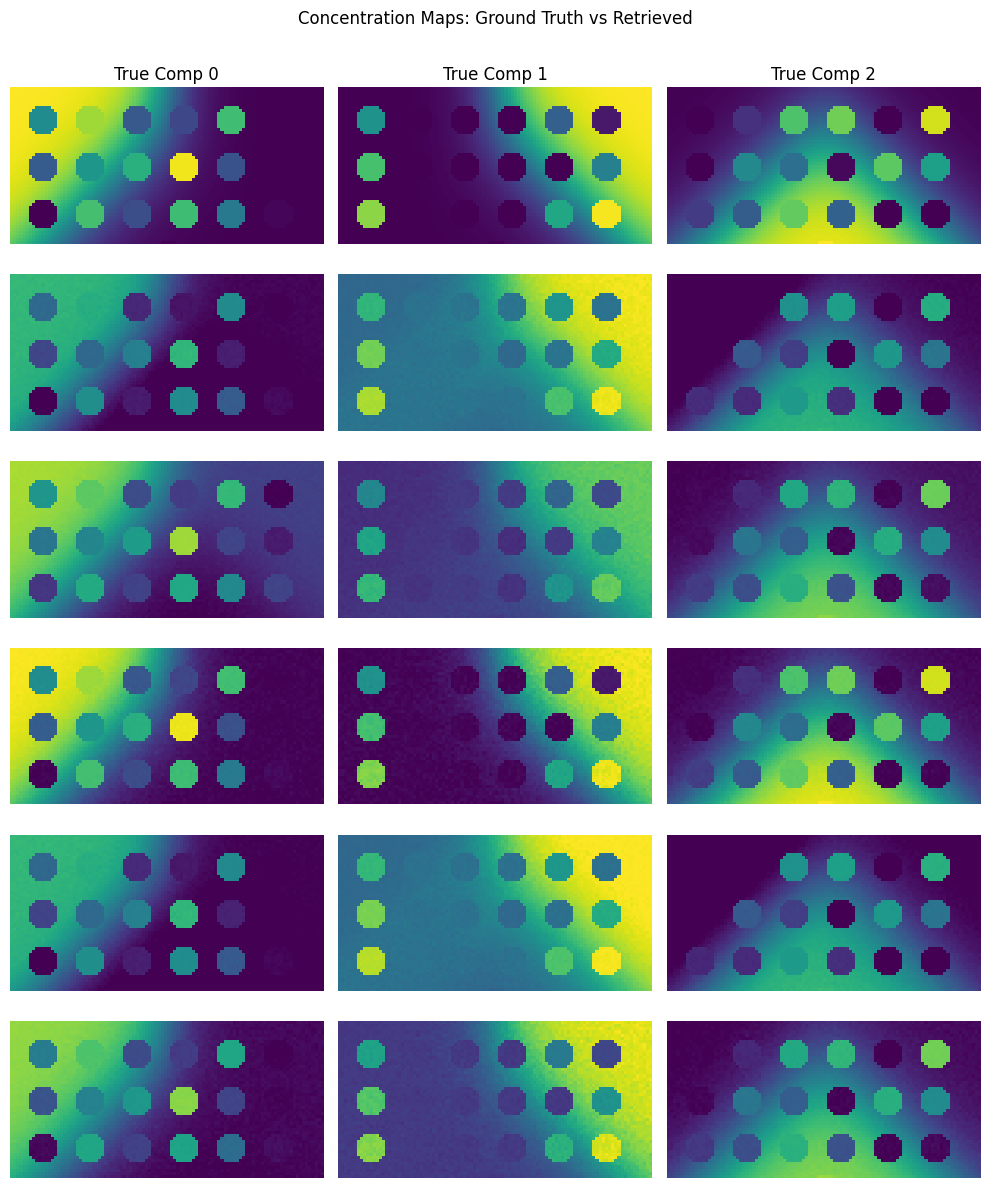

In [11]:
fig, axes = plt.subplots(len(method_names) + 1, n_components, figsize=(10, 12))

# First row: ground truth
for k in range(n_components):
    im = axes[0, k].imshow(conc[..., k], vmin=0, vmax=1)
    axes[0, k].axis("off")
    axes[0, k].set_title(f"True Comp {k}" if k > 0 else f"True Comp {k}")
axes[0, 0].set_ylabel("Ground Truth", fontsize=10, rotation=0, labelpad=80, va="center")

# Remaining rows: each method
for row, name in enumerate(method_names, start=1):
    C_opt = precomputed[name]["C_opt"]
    for k in range(n_components):
        im = axes[row, k].imshow(C_opt[:, k].reshape(M, N), vmin=0, vmax=1)
        axes[row, k].axis("off")
    axes[row, 0].set_ylabel(name, fontsize=9, rotation=0, labelpad=80, va="center")

fig.suptitle("Concentration Maps: Ground Truth vs Retrieved", y=1.0, fontsize=12)
fig.tight_layout()
plt.show()

## 6. Error Distributions

Box plots showing the distribution of errors ($\Delta\mathbf{S}$, $\Delta\mathbf{C}$, $\Delta\mathbf{D}$) across all pixels/frequencies for each method. Whiskers span the full data range.

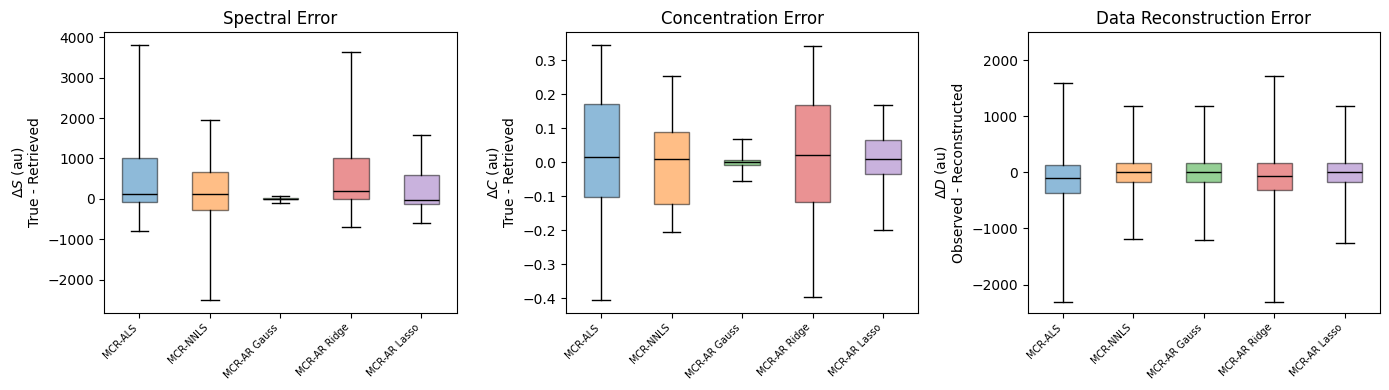

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Delta S
delta_s = [(spectra - precomputed[n]["ST_opt"]).ravel() for n in method_names]
out = axes[0].boxplot(delta_s, whis=[0, 100], patch_artist=True)
for i, box in enumerate(out["boxes"]):
    box.set_facecolor(f"C{i}")
    box.set_alpha(0.5)
    out["medians"][i].set_color("k")
axes[0].set_xticklabels(method_names, rotation=45, ha="right", fontsize=7)
axes[0].set_ylabel("$\\Delta S$ (au)\nTrue - Retrieved")
axes[0].set_title("Spectral Error")

# Delta C
delta_c = [(conc_ravel - precomputed[n]["C_opt"]).ravel() for n in method_names]
out = axes[1].boxplot(delta_c, whis=[0, 100], patch_artist=True)
for i, box in enumerate(out["boxes"]):
    box.set_facecolor(f"C{i}")
    box.set_alpha(0.5)
    out["medians"][i].set_color("k")
axes[1].set_xticklabels(method_names, rotation=45, ha="right", fontsize=7)
axes[1].set_ylabel("$\\Delta C$ (au)\nTrue - Retrieved")
axes[1].set_title("Concentration Error")

# Delta D
delta_d = [(hsi_noisy - precomputed[n]["D_opt"]).ravel() for n in method_names]
out = axes[2].boxplot(delta_d, whis=[0, 100], patch_artist=True)
for i, box in enumerate(out["boxes"]):
    box.set_facecolor(f"C{i}")
    box.set_alpha(0.5)
    out["medians"][i].set_color("k")
axes[2].set_xticklabels(method_names, rotation=45, ha="right", fontsize=7)
axes[2].set_ylabel("$\\Delta D$ (au)\nObserved - Reconstructed")
axes[2].set_title("Data Reconstruction Error")
axes[2].set_ylim(-2500, 2500)

fig.tight_layout()
plt.show()

## 7. Conclusion

**Key findings from the 5 MCR-AR variants:**

- **MCR-NNLS** achieves the lowest data reconstruction MSE (~6.3e4), making it the best choice when the goal is faithful data reproduction.
- **MCR-AR Gauss** recovers the most accurate concentration maps (NCC = 0.998, NRMSE = 0.03) and spectral shapes, but at the cost of higher reconstruction MSE (~8.4e5). The Gaussian shape constraint acts as a strong regulariser that trades data fidelity for physically meaningful spectra — a worthwhile trade when the Gaussian model assumption is correct.
- **MCR-AR Lasso** provides a good balance: competitive data MSE (~6.4e4) with high spectral accuracy (NCC = 0.994), though it is the slowest method per iteration due to the L1-regularised coordinate descent.
- **MCR-ALS** and **MCR-AR Ridge** perform similarly, with moderate accuracy across all metrics.

The choice of MCR variant depends on the application: use NNLS for best data fit, Gauss for best physical interpretability (when spectra are known to be Gaussian), and Lasso for sparse concentration recovery.